This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - always picking 5 tasks. 

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.model as model
from collections import defaultdict
import cortico_cereb_connectivity.evaluation as con_ev
import OptimalBattery.construct as ct

# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

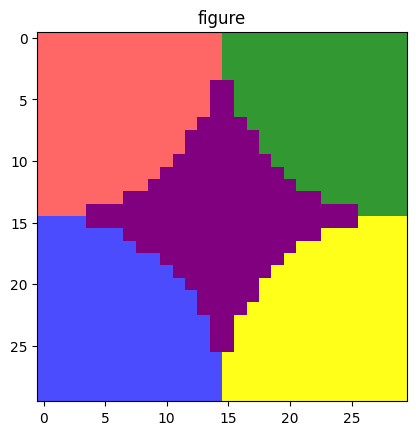

In [5]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [6]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make a random task battery with 30 task and plot second moment matrix

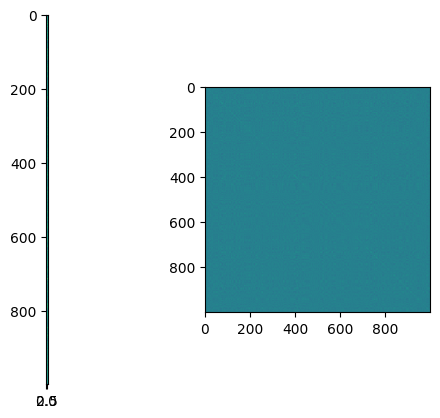

In [14]:
num_task_lib = 1000
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

In [15]:
X_true =V_lib @ np.array(U_true_5)
X_true = X_true[0]
X_true.shape

(1000, 900)

# sample connecitivity weigth matrix from a normal distribution

In [16]:
#sample connecitivity weigth matrix from a normal distribution
rng = np.random.default_rng(seed=4)
n_voxels = height * width
W = rng.normal(0,1,(n_voxels, n_voxels))

Y_true = X_true @ W

In [17]:
def center_matrix(X,axis =0):
    """Center the matrix by subtracting the mean.
    Args:
        X: matrix to center
        axis: Axis along which to center the data
    return:
        X: Centered matrix
    """
    mean = np.nanmean(X, axis=axis, keepdims=True)
    X = X - mean
    return X

def normalize_matrix(X,axis = 0):
    """Normalize the matrix by dividing by the norm.
    Args:
        X: matrix to normalize
        axis: Axis along which to normalize the data
    return:
        X: Normalized matrix
    """
    norm = np.sqrt(np.nansum(X**2, axis=axis, keepdims=True))
    norm = np.where(norm == 0, 1.0, norm)
    X = X / norm
    return X


In [18]:
def fit_model(xtrain,ytrain,method,alpha = 8):
    # initialize training dict
    # Loop over subjects
    YY  = ytrain
    XX = xtrain

    #Definitely subtract intercept across all conditions
    X = (XX - XX.mean(axis=0))
    Y = (YY - YY.mean(axis=0))
    method = method 

    # loop over subjects and train models
    alpha = np.exp(alpha) # get alpha
    conn_model = getattr(model, method)(alpha)

    # Fit model, get train and validate metrics
    conn_model.fit(X, Y)
    return conn_model



In [20]:
battery_sizes = [900]
metrics  = ['variance','log_det_mc','variance_mc','inverse_trace_mc']
results_df = pd.DataFrame()

for n_task in battery_sizes:
    print(f"Processing battery size: {n_task}")

    # Generate possible battery combinations for current battery size and evaluate each battery
    D = ct.build_combinations(G_lib, strategy='random',n_batteries=1000,n_tasks=n_task,seed=1,replacement=False)
    D = D.reset_index(drop=True)

    for metric in metrics:
        top_comb = D.iloc[D[metric].idxmax()]['combination']
        xtrain = X_true[top_comb,:]
        xtrain = center_matrix(xtrain,axis=0)
        xtrain = normalize_matrix(xtrain,axis=0)
        ytrain = Y_true[top_comb,:]
        ytrain = center_matrix(ytrain,axis=0)
        ytrain = normalize_matrix(ytrain,axis=0)
        conn_model = fit_model(xtrain,ytrain,'L2regression',alpha= 9)
        coef= conn_model.coef_

        coef_flat = coef.flatten()
        W_flat = W.flatten()

        corrcoef_matrix = np.corrcoef(coef_flat, W_flat)
        pearson_corr = corrcoef_matrix[0, 1]

        D_ev = pd.DataFrame()
        D_ev['battery_size'] = [n_task]
        D_ev['metric'] = [metric]
        D_ev['correlation'] = pearson_corr
        results_df = pd.concat([results_df,D_ev],axis=0)

Processing battery size: 900


KeyboardInterrupt: 

<Axes: xlabel='battery_size', ylabel='correlation'>

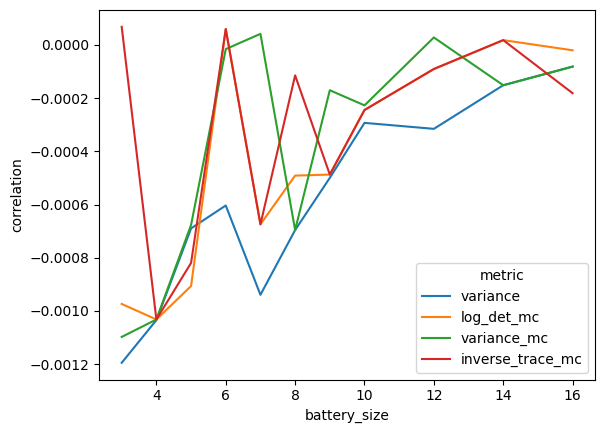

In [36]:
sns.lineplot(data=results_df,x='battery_size',y='correlation',hue='metric')